# Notebook 05: Deep Learning (Word2Vec + BiLSTM)
## SAMATRIX ResumeForge 2026 — Multiclass Resume Classification

### Objective
Implement and evaluate a recurrent neural network architecture:
1. **Word2Vec Representation**: Continuous skip-gram / CBOW embeddings trained strictly on training data (no leakage).
2. **Sequential Architecture**: `Embedding(Word2Vec)` -> `SpatialDropout` -> `Bidirectional(LSTM)` -> `Dense` -> `Softmax`.
3. **Training Dynamics**: Loss & Accuracy convergence, Early Stopping, Class Weighting.


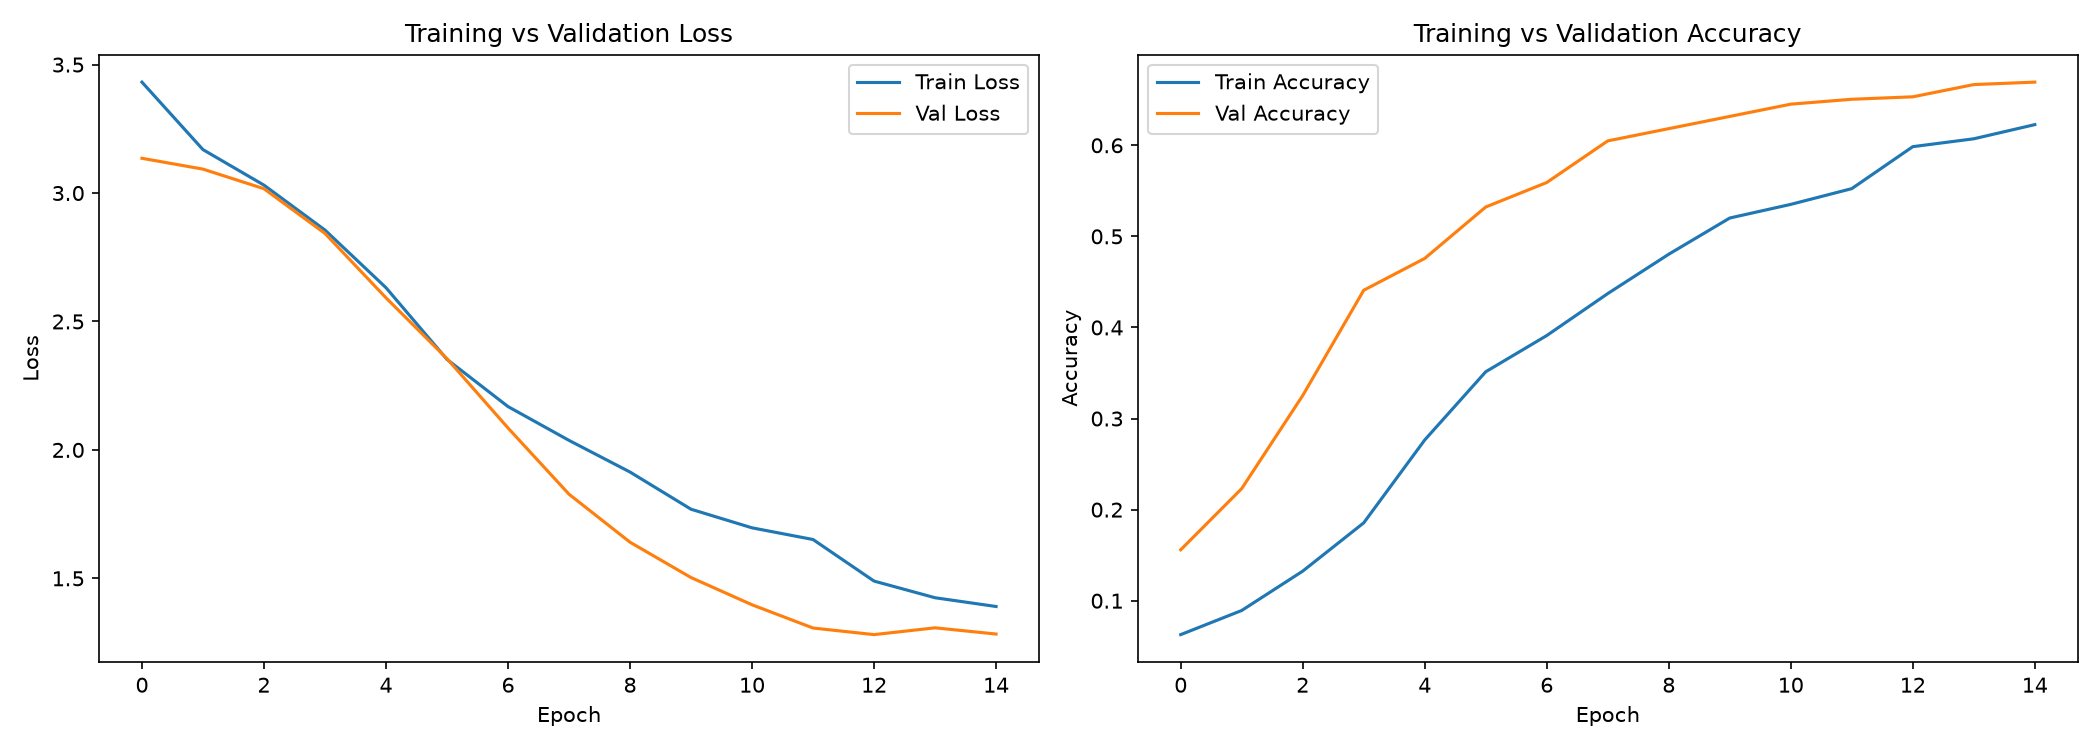

In [1]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

# Robust project root setup (works from notebooks/ or workspace root)
if os.path.exists('src'):
    PROJECT_ROOT = os.path.abspath('.')
elif os.path.exists('../src'):
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.path.abspath('.')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import FIGURES_DIR, REPORTS_DIR

# Display training curves
curve_path = os.path.join(FIGURES_DIR, 'dl_training_curves.png')
if os.path.exists(curve_path):
    from IPython.display import Image
    display(Image(filename=curve_path))
else:
    print(f"Training curves will appear at {curve_path} after pipeline execution.")


### Neural Model Architecture & Word2Vec Embeddings
The Word2Vec model captures semantic proximity between technologies (e.g. `python` is close to `django`, `flask`, `pytorch`), enabling the neural network to generalize across synonymous skills.
